# Candlestick Data Visualization

Interactive candlestick charts using Plotly for trading data analysis.

## Import Libraries

In [3]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Add parent directory to path for imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

## Load Candlestick Data

Load data from JSON file. The file should contain OHLCV data in the format:
```json
[
  {"Date": "2020-01-01 17:00:00+0000", "Open": 1.12, "High": 1.13, "Low": 1.11, "Close": 1.12, "Volume": 0.0}
]
```

In [324]:
def load_candle_data(filename):
    """Load candlestick data from JSON file."""
    filepath = Path('../data') / filename
    
    if not filepath.exists():
        raise FileNotFoundError(f"File not found: {filepath}")
    
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    df['Date'] = pd.to_datetime(df['Date'], utc=True)
    df = df.sort_values('Date')
    
    print(f"Loaded {len(df)} candles from {filename}")
    print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
    print(f"Columns: {list(df.columns)}")
    
    return df

In [325]:
# List available data files
data_dir = Path('../data')
json_files = sorted([f.name for f in data_dir.glob('*.json')])

print("Available data files:")
for i, f in enumerate(json_files, 1):
    print(f"  {i}. {f}")

Available data files:
  1. account_orders_trades_detail.json
  2. candle_data_list_frxEURUSD_300s.json
  3. candle_data_list_frxEURUSD_300s_1y.json
  4. candle_data_list_frxEURUSD_300s_3d.json
  5. candle_data_list_frxEURUSD_300s_x.json
  6. candle_data_list_frxEURUSD_3600s.json
  7. candle_data_list_frxEURUSD_900s.json


In [326]:
# Load your data file (change filename as needed)
filename = 'candle_data_list_frxEURUSD_300s.json'  # 5-minute data

df = load_candle_data(filename)
df.head()

Loaded 2342 candles from candle_data_list_frxEURUSD_300s.json
Date range: 2025-11-25 14:00:00+00:00 to 2025-12-05 17:00:00+00:00
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


,Date,Open,High,Low,Close,Volume
0,2025-11-25 14:00:00+00:00,1.15802,1.15811,1.15789,1.15800,0.0
1,2025-11-25 14:05:00+00:00,1.15799,1.15803,1.15790,1.15800,0.0
2,2025-11-25 14:10:00+00:00,1.15803,1.15803,1.15757,1.15759,0.0
3,2025-11-25 14:15:00+00:00,1.15758,1.15787,1.15758,1.15780,0.0
4,2025-11-25 14:20:00+00:00,1.15779,1.15779,1.15738,1.15753,0.0


## Plot Candlestick Chart

Create an interactive candlestick chart with volume subplot.

In [327]:
def plot_candlestick(df, title=None, show_volume=True, height=800):
    """
    Create interactive candlestick chart with optional volume subplot.
    
    Args:
        df: DataFrame with columns Date, Open, High, Low, Close, Volume
        title: Chart title (auto-generated if None)
        show_volume: Whether to show volume subplot
        height: Chart height in pixels
    """
    if title is None:
        symbol = "Unknown"
        date_range = f"{df['Date'].min().date()} to {df['Date'].max().date()}"
        title = f"Candlestick Chart - {len(df)} candles ({date_range})"
    
    # Create subplots
    if show_volume:
        fig = make_subplots(
            rows=2, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.03,
            row_heights=[0.7, 0.3],
            subplot_titles=(title, 'Volume')
        )
    else:
        fig = go.Figure()
    
    # Add candlestick chart
    candlestick = go.Candlestick(
        x=df['Date'],
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        name='OHLC',
        increasing_line_color='green',
        decreasing_line_color='red'
    )
    
    if show_volume:
        fig.add_trace(candlestick, row=1, col=1)
        
        # Add volume bars
        colors = ['green' if close >= open else 'red' 
                  for close, open in zip(df['Close'], df['Open'])]
        
        volume = go.Bar(
            x=df['Date'],
            y=df['Volume'],
            name='Volume',
            marker_color=colors,
            showlegend=False
        )
        fig.add_trace(volume, row=2, col=1)
    else:
        fig.add_trace(candlestick)
        fig.update_layout(title=title)
    
    # Update layout
    fig.update_layout(
        height=height,
        xaxis_rangeslider_visible=False,
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Update axes
    fig.update_xaxes(title_text="Date", row=2 if show_volume else 1, col=1)
    fig.update_yaxes(title_text="Price", row=1, col=1)
    if show_volume:
        fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    return fig

In [328]:
# Plot the candlestick chart
window_start = "2025-11-26 07:00:00+00:00"
window_end = "2025-12-08 07:00:00+00:00"
fig = plot_candlestick(df[(df['Date'] >= window_start) & (df['Date'] < window_end)], show_volume=True)
fig.show()

## Plot Subset of Data

Zoom in on a specific date range for detailed analysis.

In [ ]:
# Filter to specific date range
start_date = df['Date'].min()
end_date = start_date + pd.Timedelta(hours=12)  # First 12 hours

df_subset = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

print(f"Subset: {len(df_subset)} candles from {start_date} to {end_date}")

fig_subset = plot_candlestick(df_subset, title=f"Candlestick Chart (First 12 hours)", show_volume=True)
fig_subset.show()

## Add Technical Indicators (Optional)

Add simple moving averages to the candlestick chart.

In [6]:
def plot_candlestick_with_ma(df, ma_periods=[20, 50], title=None, height=800):
    """
    Create candlestick chart with moving averages.
    
    Args:
        df: DataFrame with OHLCV data
        ma_periods: List of moving average periods
        title: Chart title
        height: Chart height in pixels
    """
    if title is None:
        title = f"Candlestick Chart with Moving Averages"
    
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=[0.7, 0.3],
        subplot_titles=(title, 'Volume')
    )
    
    # Add candlestick
    fig.add_trace(
        go.Candlestick(
            x=df['Date'],
            open=df['Open'],
            high=df['High'],
            low=df['Low'],
            close=df['Close'],
            name='OHLC',
            increasing_line_color='green',
            decreasing_line_color='red'
        ),
        row=1, col=1
    )
    
    # Add moving averages
    colors = ['blue', 'orange', 'purple', 'brown']
    for i, period in enumerate(ma_periods):
        ma = df['Close'].rolling(window=period).mean()
        fig.add_trace(
            go.Scatter(
                x=df['Date'],
                y=ma,
                name=f'MA{period}',
                line=dict(color=colors[i % len(colors)], width=1.5)
            ),
            row=1, col=1
        )
    
    # Add volume
    colors = ['green' if close >= open else 'red' 
              for close, open in zip(df['Close'], df['Open'])]
    
    fig.add_trace(
        go.Bar(
            x=df['Date'],
            y=df['Volume'],
            name='Volume',
            marker_color=colors,
            showlegend=False
        ),
        row=2, col=1
    )
    
    # Update layout
    fig.update_layout(
        height=height,
        xaxis_rangeslider_visible=False,
        hovermode='x unified',
        template='plotly_white'
    )
    
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    return fig

In [ ]:
# Plot with moving averages
fig_ma = plot_candlestick_with_ma(df, ma_periods=[20, 50], title="Candlestick with MA20 and MA50")
fig_ma.show()

## Compare Multiple Timeframes

Load and compare data at different timeframes.

In [10]:
# Example: Load both 5m and 1h data if available
# Uncomment and adjust filenames as needed

# df_5m = load_candle_data('candle_data_list_frxEURUSD_300s.json')
# df_1h = load_candle_data('candle_data_list_frxEURUSD_3600s.json')

# fig_5m = plot_candlestick(df_5m, title="5-Minute Chart", height=400)
# fig_1h = plot_candlestick(df_1h, title="1-Hour Chart", height=400)

# fig_5m.show()
# fig_1h.show()

## Plot trades

Plot a recent backtest onto the candle data

In [329]:
# Same candlestick chart as before but with trade data

# Plot the candlestick chart
    
window_start = "2025-11-26 07:00:00+00:00"
window_end = "2025-12-08 07:00:00+00:00"

# Configure the path to the backtest results JSON
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go

results_path = Path("../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json")


with open(results_path, "r") as f:
    eval_payload = json.load(f)

trades_raw = eval_payload.get("trades_detail", [])

# If no trades found, bail out gracefully
if not trades_raw:
    print("No trades_detail found in the results JSON.")
else:
    trades_df = pd.DataFrame(trades_raw)

    # Parse times to timezone-aware datetimes (backtester writes ISO timestamps in UTC)
    for col in ("entry_time", "exit_time"):
        if col in trades_df.columns:
            trades_df[col] = pd.to_datetime(trades_df[col], utc=True, errors="coerce")

    # Choose which candle DataFrame window you want to overlay on:
    # - For full chart use df
    # - For a zoomed chart use df_subset (if created in a previous cell)
    candles_window = df[(df['Date'] >= window_start) & (df['Date'] < window_end)]  # or df_subset

    # Filter trades to the visible candle window for clarity
    # window_start = candles_window["Date"].min()
    # window_end = candles_window["Date"].max()

    trades_vis = trades_df[(trades_df["entry_time"] >= window_start) & (trades_df["entry_time"] <= window_end)].copy()

    # Optional: cap number of plotted trades to keep the figure responsive
    MAX_TRADES = 800000
    if len(trades_vis) > MAX_TRADES:
        trades_vis = trades_vis.tail(MAX_TRADES)

    # Split by side for coloring/markers
    buys = trades_vis[trades_vis["direction"] == "BUY"].copy()
    sells = trades_vis[trades_vis["direction"] == "SELL"].copy()

    # Helper to add entry markers
    def add_entry_markers(fig_obj, df_side, side_name, color, marker_symbol):
        if df_side.empty:
            return
        hoverdata = pd.DataFrame({
            "Side": df_side["direction"],
            "Size": df_side.get("size", pd.Series([None]*len(df_side))),
            "SL": df_side.get("stop_price", pd.Series([None]*len(df_side))),
            "TP": df_side.get("take_profit_price", pd.Series([None]*len(df_side))),
        })
        fig_obj.add_trace(go.Scatter(
            x=df_side["entry_time"],
            y=df_side["entry_price"],
            mode="markers",
            name=f"{side_name} Entry",
            marker=dict(color=color, symbol=marker_symbol, size=9, line=dict(color="black", width=0.5)),
            customdata=hoverdata[["Side", "Size", "SL", "TP"]].to_numpy(),
            hovertemplate="<b>%{customdata[0]}</b><br>"
                          "Entry: %{y:.5f}<br>"
                          "Size: %{customdata[1]:.2f}<br>"
                          "SL: %{customdata[2]:.5f}<br>"
                          "TP: %{customdata[3]:.5f}<br>"
                          "Time: %{x|%Y-%m-%d %H:%M:%S %Z}<extra></extra>",
            showlegend=True
        ))

    # Helper to add exit markers
    def add_exit_markers(fig_obj, df_side, side_name, color):
        df_side = df_side.dropna(subset=["exit_time", "exit_price"])
        if df_side.empty:
            return
        hoverdata = pd.DataFrame({
            "PnL": df_side.get("pnl", pd.Series([None]*len(df_side))),
            "ExitPx": df_side["exit_price"],
        })
        fig_obj.add_trace(go.Scatter(
            x=df_side["exit_time"],
            y=df_side["exit_price"],
            mode="markers",
            name=f"{side_name} Exit",
            marker=dict(color=color, symbol="x", size=8, line=dict(color="black", width=0.5), opacity=0.85),
            customdata=hoverdata[["PnL", "ExitPx"]].to_numpy(),
            hovertemplate="<b>Exit</b><br>"
                          "Exit: %{customdata[1]:.5f}<br>"
                          "PnL: %{customdata[0]:.2f}<br>"
                          "Time: %{x|%Y-%m-%d %H:%M:%S %Z}<extra></extra>",
            showlegend=True
        ))

    # Helper to draw entry->exit lines (optional)
    def add_entry_exit_lines(fig_obj, df_side, color, opacity=0.35, width=1.5):
        df_side = df_side.dropna(subset=["exit_time", "exit_price"])
        if df_side.empty:
            return
        # One trace per trade keeps hover clean but can be heavy for thousands of trades.
        # For performance, you could aggregate by batching, but this keeps it simple/readable.
        for _, r in df_side.iterrows():
            fig_obj.add_trace(go.Scatter(
                x=[r["entry_time"], r["exit_time"]],
                y=[r["entry_price"], r["exit_price"]],
                mode="lines",
                line=dict(color=color, width=width),
                opacity=opacity,
                hoverinfo="skip",
                showlegend=False
            ))

    # Pick the figure to overlay on (fig for full, or fig_subset for zoomed)
    target_fig = fig  # or fig_subset

    # Add overlays
    add_entry_markers(target_fig, buys, "Buy", color="seagreen", marker_symbol="triangle-up")
    add_entry_markers(target_fig, sells, "Sell", color="crimson", marker_symbol="triangle-down")
    add_exit_markers(target_fig, buys, "Buy", color="darkgreen")
    add_exit_markers(target_fig, sells, "Sell", color="darkred")

    # Toggle to draw lines between entry and exit
    SHOW_LINES = True
    if SHOW_LINES:
        add_entry_exit_lines(target_fig, buys, color="seagreen", opacity=0.30, width=1.2)
        add_entry_exit_lines(target_fig, sells, color="crimson", opacity=0.30, width=1.2)

    # Optional: tighten the y-range around visible data
    # target_fig.update_yaxes(range=[candles_window["Low"].min(), candles_window["High"].max()])

    # target_fig.show()

In [330]:
target_fig.show()

## Export Chart to HTML

Save the interactive chart as an HTML file for sharing.

In [12]:
# Save chart to HTML file
output_dir = Path('../scripts/outputs')
output_dir.mkdir(exist_ok=True)

output_file = output_dir / 'candlestick_chart.html'
fig.write_html(str(output_file))

print(f"Chart saved to: {output_file}")

Chart saved to: ../scripts/outputs/candlestick_chart.html


## My own plotting of history and training results

In [6]:
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner outputrt json
import os
import sys
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import datetime as dt

In [15]:
# Path("../results_2025-11-19_best/keltner_squeeze_breakout/evaluations/full_dataset_backtest_3day_test.json"),
results_paths = [
Path("../results_2025-11-19_best/keltner_squeeze_breakout/evaluations/full_dataset_backtest_maxls01_r5.json"),
Path("../results_2025-11-19_best/keltner_squeeze_breakout/evaluations/full_dataset_backtest_maxls10_r5_maxcc1.json"),
Path("../results_2025-11-19_best/keltner_squeeze_breakout/evaluations/full_dataset_backtest_maxls100_r5.json")]

results_paths = [
Path("../results_2025-11-19_best/keltner_squeeze_breakout/evaluations/full_dataset_backtest_maxls100_r5.json")]

results_paths = [
    Path("../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json")]

../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json


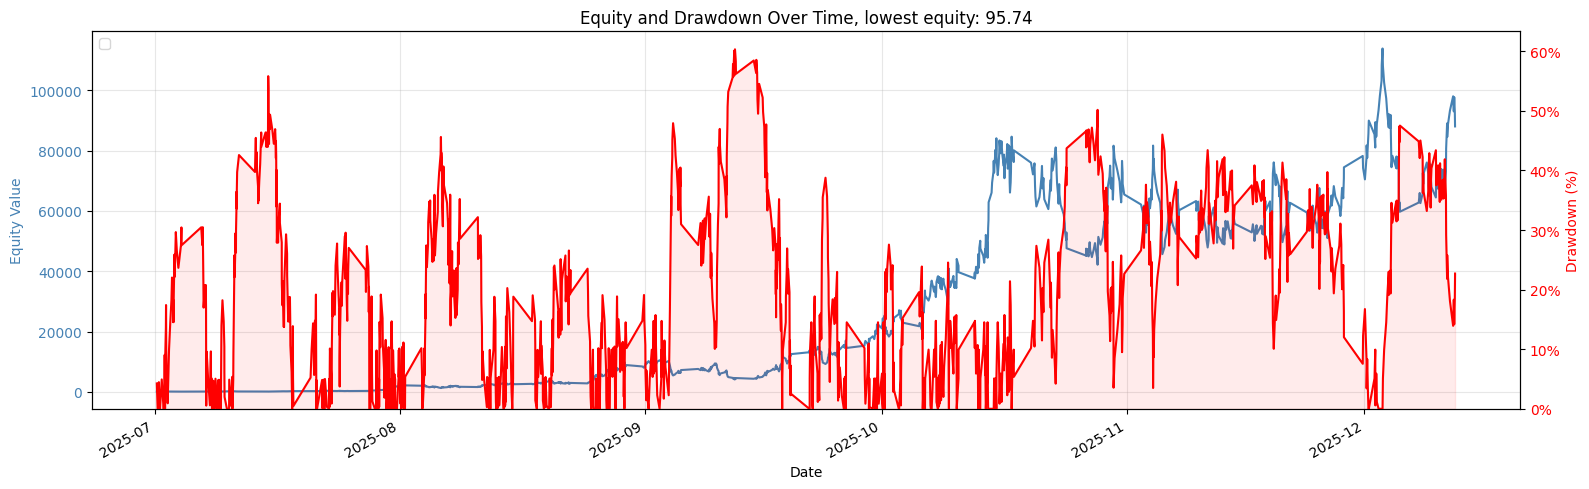

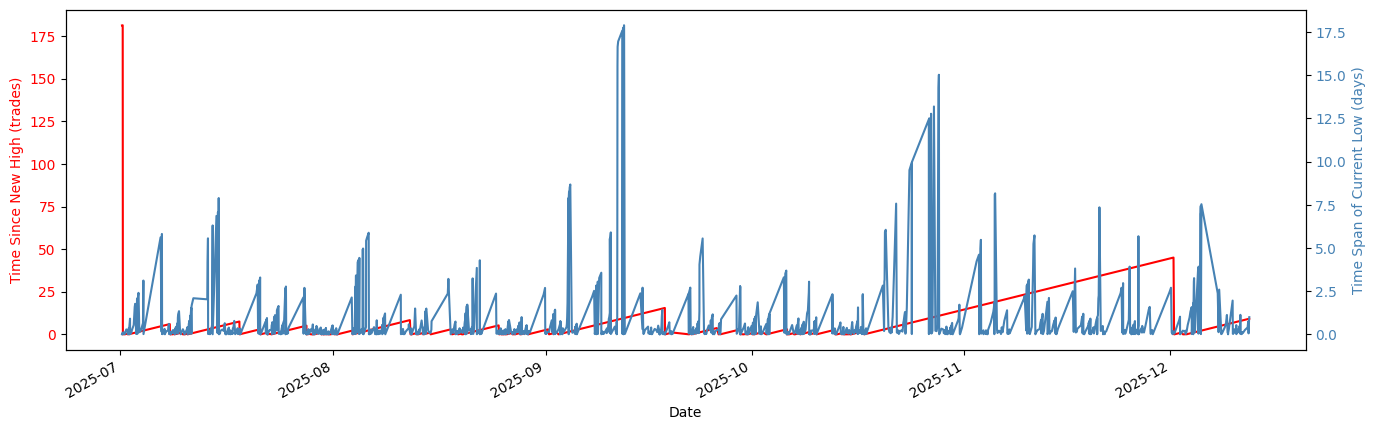

In [16]:
# Plot drawdown/equity curve from trades_detail

for results_path in results_paths:
    # print(results_path)
    with open(results_path, "r") as f:
        eval_payload = json.load(f)

    equity = [100]
    lot_sizes = [None]
    last_high = 100
    drop_from_previous_high = [0]
    drop_from_previous_high_perc = [0]
    drop_from_previous_high_per_lot = [0]
    date_times = ["2025-01-01T00:00:00+00:00"]
    for ii in eval_payload['trades_detail']:
        date_times.append(ii['exit_time'])
        lot_sizes.append(ii['size'])
        equity.append(equity[-1] + ii['pnl'])
        last_high = max(last_high, equity[-1])
        
        drop_from_previous_high.append(last_high - equity[-1])
        drop_from_previous_high_perc.append((last_high - equity[-1]) / last_high * 100)
        drop_from_previous_high_per_lot.append((last_high - equity[-1]) / ii['size'] if ii['size'] != 0 else 0)
        
    equity_data = pd.DataFrame({
        "Date": pd.to_datetime(date_times, utc=True),
        "Equity": equity,
        "Drawdown": drop_from_previous_high,
        "DrawdownPerc": drop_from_previous_high_perc,
        "lot_size": lot_sizes,
        "DrawdownPerLot": drop_from_previous_high_per_lot
    })
    
    equity_data.set_index("Date", inplace=True)
    equity_data.sort_index(inplace=True)
    
    time_since_new_high = []
    last_high_time = equity_data.index[0]
    for row in equity_data.iterrows():
        ii_dt = row[0]
        if row[1]['Drawdown'] == 0:
            last_high_time = ii_dt
            delta = (ii_dt - last_high_time).total_seconds() / (3600 * 24)  # Convert to days
            time_since_new_high.append(delta)
        else:
            delta = (ii_dt - last_high_time).total_seconds() / (3600 * 24)  # Convert to days
            time_since_new_high.append(delta)
            
    equity_data['TimeSinceNewHigh'] = time_since_new_high


    timespan_of_current_low = []
    testing = []
    equity_data_layered = pd.DataFrame({'Date': [], 'Equity': []})
    equity_data_layered.set_index('Date', inplace=True)
    for row in equity_data.iterrows():
        current_equity = row[1]['Equity']
        if not equity_data_layered.empty:
            df_lower_points = equity_data_layered[equity_data_layered <= current_equity].dropna()
        else:
            df_lower_points = pd.DataFrame()
        if not df_lower_points.empty:
            timespan_of_current_low.append((row[0] - df_lower_points.iloc[-1].name).total_seconds() / (3600 * 24))  # Convert to days
        else:
            timespan_of_current_low.append(0)
        equity_data_layered.loc[row[0]] = row[1]['Equity']
    
    equity_data['TimeSpanOfCurrentLow'] = timespan_of_current_low
    
        
    start_plot_date = "2025-01-01 00:00:00+00:00"
    start_plot_date = "2025-07-01 00:00:00+00:00"
    end_plot_date = "2025-12-15 00:00:00+00:00"

    # Define the data to be plotted
    plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
    plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']
    plot_data_drawdown_per_lot = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerLot']
    plot_data_time_since_new_high = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['TimeSinceNewHigh']
    plot_data_timespan_of_current_low = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['TimeSpanOfCurrentLow']

    import matplotlib.pyplot as plt

    # Assumes:
    #   plot_data_equity: pandas Series indexed by datetime
    #   plot_data_drawdown: pandas Series (percent values, e.g. 0–30) indexed by same datetime
    # If indexes differ, you can align first: common_index = plot_data_equity.index.intersection(plot_data_drawdown.index)

    fig, ax1 = plt.subplots(figsize=(16, 5))

    # Primary axis: Equity
    line1 = plot_data_equity.plot(ax=ax1, color='steelblue', label='Equity')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Equity Value", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    # ax1.set_ylim(bottom=0)

    # Secondary axis: Drawdown %
    ax2 = ax1.twinx()
    line2 = plot_data_drawdown.plot(ax=ax2, color='red', label='Drawdown %')
    ax2.set_ylabel("Drawdown (%)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(bottom=0)

    # Optional: format drawdown y-axis as integer percentages
    from matplotlib.ticker import PercentFormatter
    ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

    # Grid (use primary axis grid so it doesn’t duplicate)
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')


    plt.title(f"Equity and Drawdown Over Time, lowest equity: {plot_data_equity.min():.2f}")
    plt.tight_layout()
    plt.close(fig)

    ax2.fill_between(plot_data_drawdown.index,
                    plot_data_drawdown,
                    0,
                    color='red',
                    alpha=0.08,
                    label='_nolegend_')
    plt.show()
    
    fig3, ax4 = plt.subplots(figsize=(16, 5))

    # Primary axis: Equity
    # line3 = plot_data_drawdown_per_lot.plot(ax=ax3, color='steelblue', label='Equity')
    # ax3.set_xlabel("Date")
    # ax3.set_ylabel("Equity Drop per lot", color='steelblue')
    # ax3.tick_params(axis='y', labelcolor='steelblue')
    # ax3.set_ylim(bottom=0)
    line4 = plot_data_time_since_new_high.plot(ax=ax4, color='red', label='Time Since New High')
    ax4.set_ylabel("Time Since New High (trades)", color='red')
    ax4.tick_params(axis='y', labelcolor='red')
    
    ax3 = ax4.twinx()
    line3 = plot_data_timespan_of_current_low.plot(ax=ax3, color='steelblue', label='Time Span of Current Low')
    ax3.set_xlabel("Date")
    ax3.set_ylabel("Time Span of Current Low (days)", color='steelblue')
    ax3.tick_params(axis='y', labelcolor='steelblue')
    
    plt.close(fig3)
    
    print(results_path)
    display(fig)
    display(fig3)

In [11]:
equity_data.iloc[15:]

,Equity,Drawdown,DrawdownPerc,lot_size,DrawdownPerLot,TimeSinceNewHigh,TimeSpanOfCurrentLow
Date,,,,,,,
2025-01-02 11:05:00+00:00,112.546,0.00,0.000000,0.05,0.0,0.000000,0.003472
2025-01-02 11:10:00+00:00,117.836,0.00,0.000000,0.05,0.0,0.000000,0.003472
2025-01-02 11:15:00+00:00,112.516,5.32,4.514749,0.05,106.4,0.003472,0.010417
2025-01-02 11:20:00+00:00,107.196,10.64,9.029499,0.05,212.8,0.006944,0.034722
2025-01-02 11:35:00+00:00,112.486,5.35,4.540208,0.05,107.0,0.017361,0.010417
...,...,...,...,...,...,...,...
2025-12-05 10:05:00+00:00,45812.688,1067.00,2.276039,1.00,1067.0,2.076389,7.003472
2025-12-05 10:20:00+00:00,45706.288,1173.40,2.503003,1.00,1173.4,2.086806,7.059028
2025-12-05 10:55:00+00:00,45599.888,1279.80,2.729967,1.00,1279.8,2.111111,7.329861


In [284]:
len(equity_data_layered) < 1

15

In [300]:
timespan_of_current_low = []
testing = []
equity_data_layered = pd.DataFrame({'Date': [], 'Equity': []})
equity_data_layered.set_index('Date', inplace=True)
for row in equity_data.iloc[0:15].iterrows():
    current_equity = row[1]['Equity']
    if not equity_data_layered.empty:
        df_lower_points = equity_data_layered[equity_data_layered <= current_equity].dropna()
    else:
        df_lower_points = pd.DataFrame()
    if not df_lower_points.empty:
        timespan_of_current_low.append((row[0] - df_lower_points.iloc[-1].name).total_seconds() / (3600 * 24))  # Convert to days
    else:
        print("df_lower_points is empty")
        timespan_of_current_low.append(0)
    equity_data_layered.loc[row[0]] = row[1]['Equity']

df_lower_points is empty
df_lower_points is empty
df_lower_points is empty


In [301]:
# equity_data_layered.sort_index()
equity_data_layered
timespan_of_current_low

[0,
 0.020833333333333332,
 0.003472222222222222,
 0.003472222222222222,
 0.010416666666666666,
 0.034722222222222224,
 0.010416666666666666,
 0.2638888888888889,
 0.3784722222222222,
 0.04513888888888889,
 0.4513888888888889,
 0.7256944444444444,
 0,
 0,
 0.017361111111111112]

In [219]:
df_lower_points = equity_data_layered[equity_data_layered < current_equity].dropna()
if df_lower_points.empty:
    None
else:
    df_lower_points.iloc[-1].name

In [218]:
if df_lower_points.empty:
    None

In [222]:
timespan_of_current_low = [pd.Timedelta(0)]
equity_data_layered = pd.DataFrame({'Date': [], 'Equity': []})
equity_data_layered.set_index('Date', inplace=True)
for row in equity_data.iterrows():
    current_equity = row[1]['Equity']
    equity_data_layered.loc[row[0]] = row[1]['Equity']
    df_lower_points = equity_data_layered[equity_data_layered < current_equity].dropna()
    if not df_lower_points.empty:
        timespan_of_current_low.append(row[0] - df_lower_points.iloc[-1].name)
    else:
        timespan_of_current_low.append(pd.Timedelta(0))
        
timespan_of_current_low

[Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('-2 days +15:15:00'),
 Timedelta('0 days 00:30:00'),
 Timedelta('0 days 00:05:00'),
 Timedelta('0 days 00:05:00'),
 Timedelta('0 days 00:15:00'),
 Timedelta('0 days 00:50:00'),
 Timedelta('0 days 00:15:00'),
 Timedelta('0 days 06:20:00'),
 Timedelta('0 days 09:05:00'),
 Timedelta('0 days 01:05:00'),
 Timedelta('0 days 10:50:00'),
 Timedelta('0 days 17:25:00'),
 Timedelta('-1 days +10:05:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:25:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:10:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 04:20:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 00:00:00'),
 Timedelta('0 days 05:40:00'),
 Timedelta('0 days 00:30:00'),
 Timedelta('0 days 00:10:00'),
 Timedelta('0 days 00:15:00'),
 Timedelta('0 days 00:35:00'),
 Timedelta('0 days 00:05:00'),
 Tim

In [97]:
plot_data_drawdown_time_since_new_high

equity_data


time_since_new_high = []
last_high_time = equity_data.index[0]
for row in equity_data.iterrows():
    # print(row[0], row[1]['Equity'], row[1]['Drawdown'])
    ii_dt = row[0]
    if row[1]['Drawdown'] == 0:
        last_high_time = ii_dt
        time_since_new_high.append(0)
    else:
        delta = ii_dt - last_high_time
        time_since_new_high.append(delta)
        
equity_data['TimeSinceNewHigh'] = time_since_new_high

equity_data
time_since_new_high[7]

Timedelta('0 days 00:25:00')

../results_2025-11-19_best/keltner_squeeze_breakout/evaluations/full_dataset_backtest_maxls100_r5.json


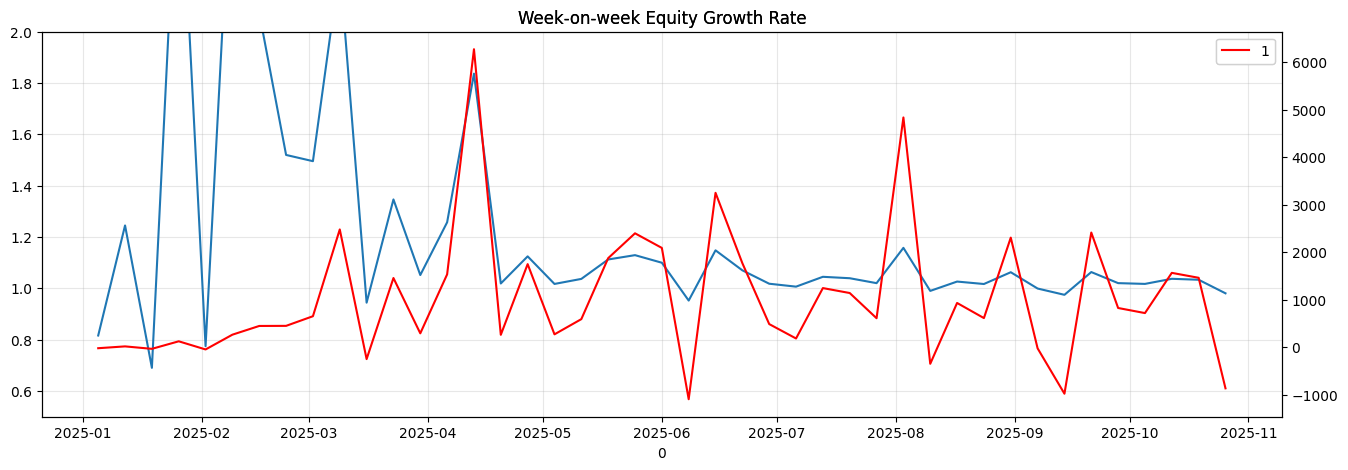

In [44]:
# Plot drawdown/equity curve from trades_detail
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt

for results_path in results_paths:
    print(results_path)
    with open(results_path, "r") as f:
        eval_payload = json.load(f)

    equity = [100]
    last_high = 100
    drop_from_previous_high = [0]
    drop_from_previous_high_perc = [0]
    date_times = ["2025-01-02T09:00:00+00:00"]
    for ii in eval_payload['trades_detail']:
        date_times.append(ii['exit_time'])
        equity.append(equity[-1] + ii['pnl'])
        last_high = max(last_high, equity[-1])
        
        drop_from_previous_high.append(last_high - equity[-1])
        drop_from_previous_high_perc.append((last_high - equity[-1]) / last_high * 100)
        
    equity_data = pd.DataFrame({
        "Date": pd.to_datetime(date_times, utc=True),
        "Equity": equity,
        "Drawdown": drop_from_previous_high,
        "DrawdownPerc": drop_from_previous_high_perc
    })

    equity_data.set_index("Date", inplace=True)
    
    cur_equity_set = []
    week_on_week_equity = [[dt.datetime(2024, 12, 30).date(), np.float64(100.0)]]
    week_on_week_equity_growth = []
    week_on_week_equity_rate = []
    concurrent_trades_count = []
    cur_weekday = 0
    last_weekday = 0
    for row in equity_data.iterrows():
        cur_weekday = row[0].weekday()
        if cur_weekday >= last_weekday:
            cur_equity_set.append([row[0].date(), row[1][0]])
            last_weekday = cur_weekday
        elif cur_weekday < last_weekday:
            week_on_week_equity.append([cur_equity_set[-1][0], cur_equity_set[-1][1]])
            week_on_week_equity_rate.append([week_on_week_equity[-1][0] , week_on_week_equity[-1][1] / week_on_week_equity[-2][1]])
            week_on_week_equity_growth.append([week_on_week_equity[-1][0] , week_on_week_equity[-1][1] - week_on_week_equity[-2][1]])
            cur_equity_set = []
            cur_equity_set.append([row[0].date(), row[1][0]])
            last_weekday = cur_weekday
            
    week_on_week_equity_df = pd.DataFrame(week_on_week_equity)
    week_on_week_equity_rate_df = pd.DataFrame(week_on_week_equity_rate)
    week_on_week_equity_growth_df = pd.DataFrame(week_on_week_equity_growth)

    fig3, ax3 = plt.subplots(figsize=(16, 5))
    line1 = week_on_week_equity_rate_df.plot(ax=ax3, x=0, y=1, figsize=(16,5), title="Week-on-week Equity Growth Rate")
    ax3.set_ylim([0.5, 2.0])
    ax4 = ax3.twinx()
    line2 = week_on_week_equity_growth_df.plot(ax=ax4, x=0, y=1, figsize=(16,5), color='red', title="Week-on-week Equity Growth Rate")
    ax3.grid(True, alpha=0.3)
    # ax3.set_ylim([0, 20])



In [45]:
WL = [x['pnl']>0 for x in eval_payload['trades_detail']]
wl = []
ll = []
cs = 0
prev_ii = WL[0]
for ii in WL:
    if ii == prev_ii:
        cs += 1
    else:
        if prev_ii:
            wl.append(cs)
        else:
            ll.append(cs)
        prev_ii = ii
        cs = 1

(array([522., 253., 140.,  65.,  32.,  11.,   5.,   4.,   2.,   1.,   1.]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.]),
 <BarContainer object of 11 artists>)

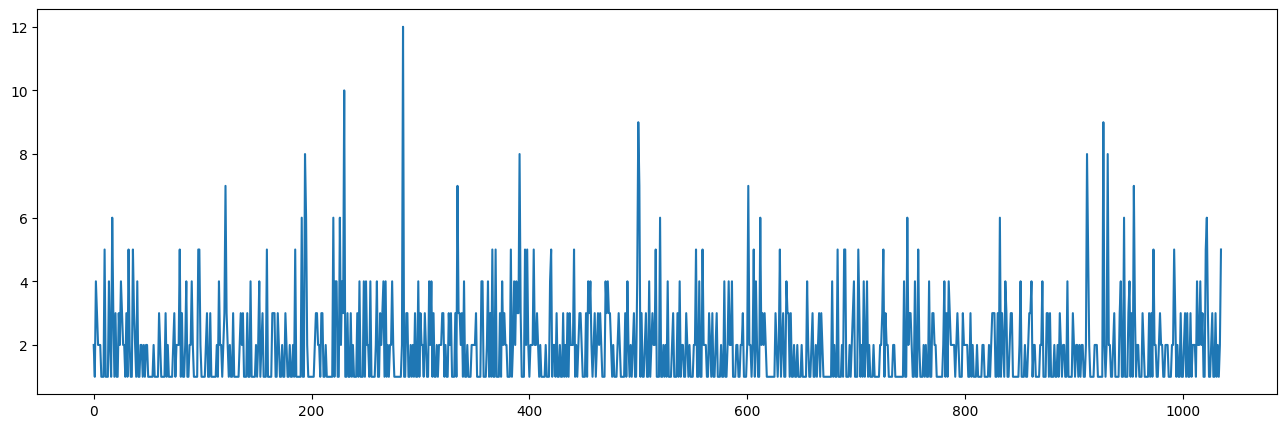

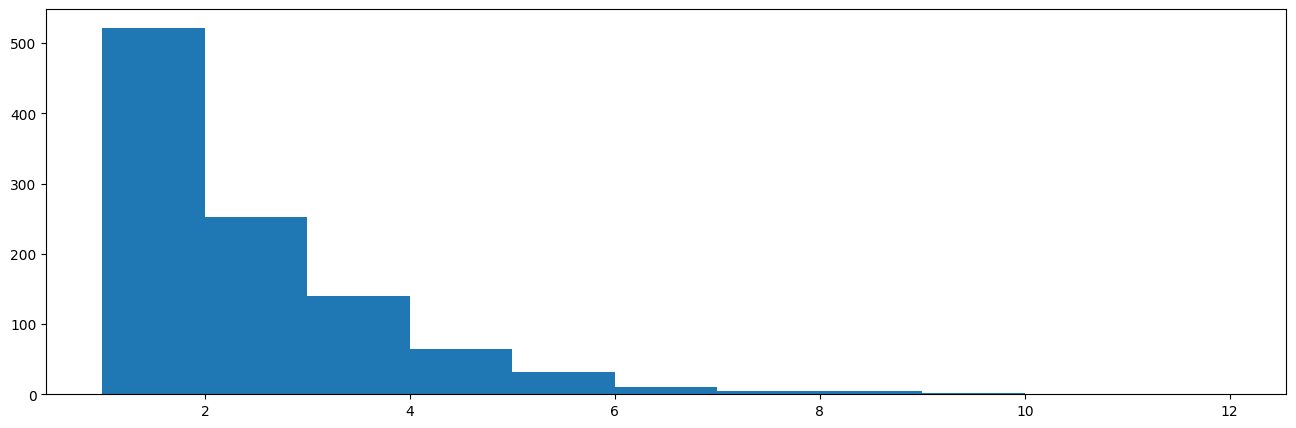

In [46]:
fig5, ax5 = plt.subplots(figsize=(16, 5))
fig6, ax6 = plt.subplots(figsize=(16, 5))

# ax5.plot(wl)
ax5.plot(ll)
np.mean(ll)
ax6.hist(ll, bins=max(ll)-1)

In [47]:
eval_payload_df = pd.DataFrame(eval_payload['trades_detail'])
eval_payload_df['win_lose'] = eval_payload_df['pnl'] > 0
eval_payload_df['entry_time_td'] = pd.to_datetime(eval_payload_df['entry_time']).dt.time
eval_payload_df['entry_time_td'] = pd.to_timedelta(eval_payload_df['entry_time_td'].astype(str))
eval_payload_df['entry_time_td_frac'] = eval_payload_df['entry_time_td']/pd.Timedelta('1 days')

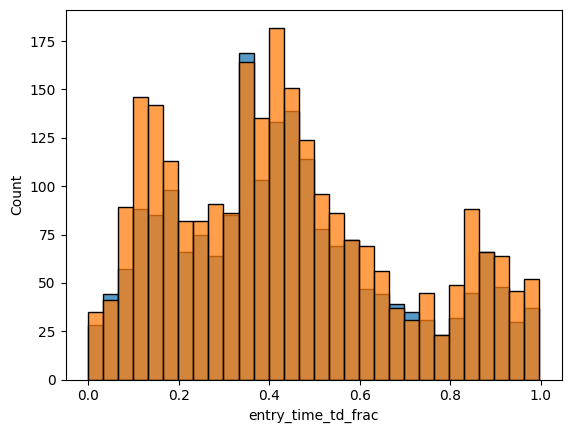

In [48]:
import seaborn as sns

sns.histplot(data=eval_payload_df[eval_payload_df['win_lose']==False], x='entry_time_td_frac', bins=30)
sns.histplot(data=eval_payload_df[eval_payload_df['win_lose']==True], x='entry_time_td_frac', bins=30)

plt.show()

# fig3, ax3 = plt.subplots(figsize=(16, 5))
#     line1 = week_on_week_equity_rate_df.plot(ax=ax3, x=0, y=1, figsize=(16,5), title="Week-on-week Equity Growth Rate")

<Axes: title={'center': 'Equity Over Time'}, xlabel='entry_time'>

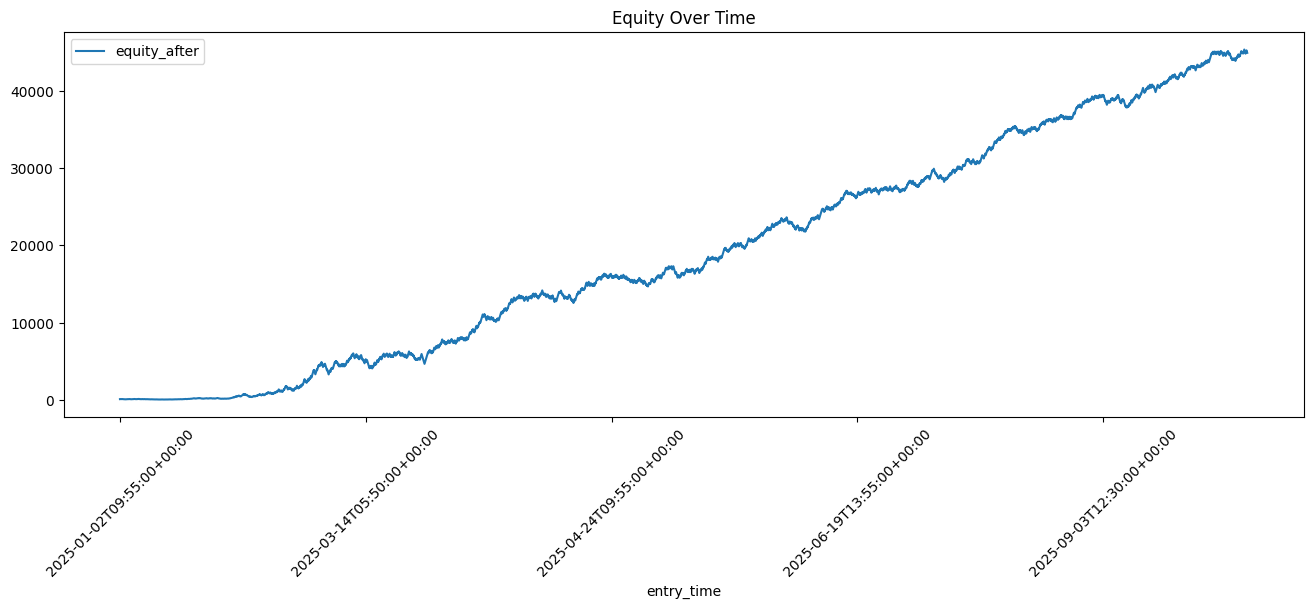

In [49]:
eval_payload_df[eval_payload_df['entry_time'] < "2025-12-31T00:00:00+00:00"][['entry_time', 'equity_after']].plot(x='entry_time', y='equity_after', figsize=(16,5), title="Equity Over Time",rot=45)

<Axes: title={'center': 'Equity Over Time'}, xlabel='entry_time'>

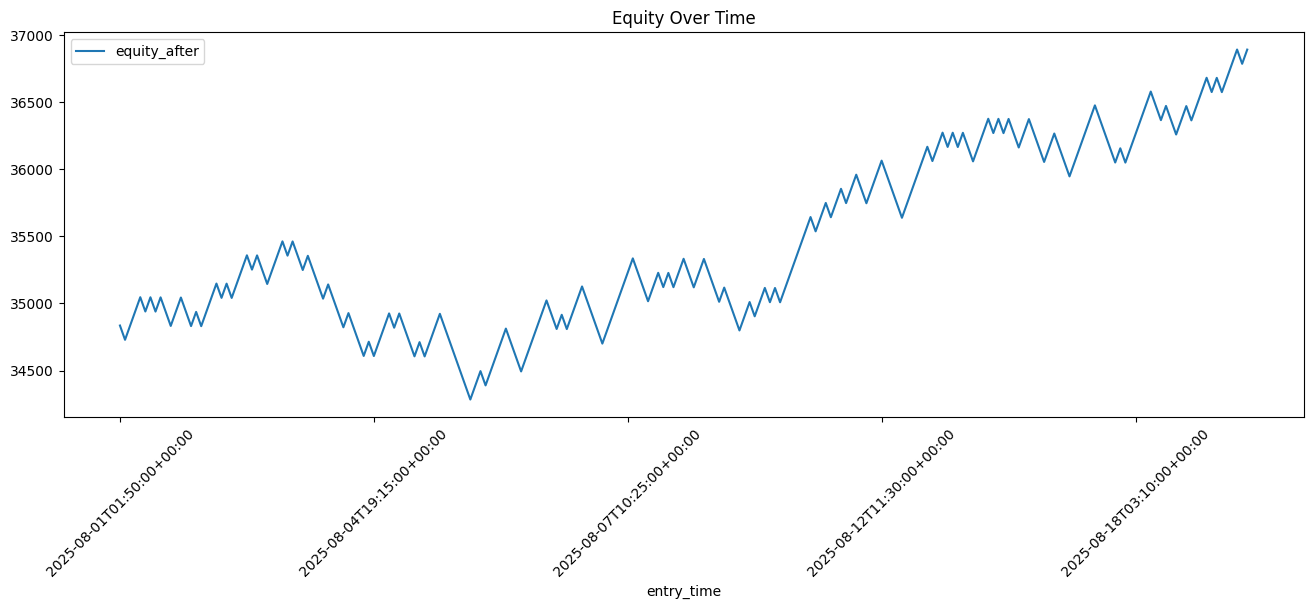

In [65]:
start_plot = "2025-08-01T00:00:00+00:00"
end_plot = "2025-08-20T00:00:00+00:00"
eval_payload_df[(eval_payload_df['entry_time'] > start_plot) & (eval_payload_df['entry_time'] < end_plot)][['entry_time', 'equity_after']].plot(x='entry_time', y='equity_after', figsize=(16,5), title="Equity Over Time",rot=45)


In [148]:
eval_payload_df[(eval_payload_df['entry_time'] > "2025-01-07T00:00:00+00:00") & (eval_payload_df['entry_time'] < "2025-01-20T00:00:00+00:00")].head(60)

,direction,entry_time,entry_price,stop_price,take_profit_price,exit_time,exit_price,size,stop_distance_pips,size_pre_cap,size_after_leverage_cap,size_after_rounding,size_after_max_cap,pnl,equity_after,win_lose,entry_time_td,entry_time_td_frac
47,BUY,2025-01-07T00:30:00+00:00,1.03959,1.038546,1.040668,2025-01-07T02:10:00+00:00,1.040648,0.04,10.44,0.042984,0.042984,0.04,0.04,4.232,93.98,True,0 days 00:30:00,0.020833
48,BUY,2025-01-07T02:15:00+00:00,1.04081,1.039766,1.041888,2025-01-07T02:40:00+00:00,1.041868,0.04,10.44,0.045010,0.045010,0.04,0.04,4.232,98.21,True,0 days 02:15:00,0.093750
49,BUY,2025-01-07T02:40:00+00:00,1.04131,1.040266,1.042388,2025-01-07T02:45:00+00:00,1.042368,0.04,10.44,0.047035,0.047035,0.04,0.04,4.232,102.44,True,0 days 02:40:00,0.111111
50,SELL,2025-01-07T03:35:00+00:00,1.04072,1.041764,1.039642,2025-01-07T03:50:00+00:00,1.041784,0.04,10.44,0.049061,0.049061,0.04,0.04,-4.256,98.18,False,0 days 03:35:00,0.149306
51,BUY,2025-01-07T04:00:00+00:00,1.04210,1.041056,1.043178,2025-01-07T04:05:00+00:00,1.043158,0.04,10.44,0.047021,0.047021,0.04,0.04,4.232,102.41,True,0 days 04:00:00,0.166667
52,BUY,2025-01-07T04:05:00+00:00,1.04269,1.041646,1.043768,2025-01-07T06:20:00+00:00,1.041626,0.04,10.44,0.049047,0.049047,0.04,0.04,-4.256,98.15,False,0 days 04:05:00,0.170139
53,SELL,2025-01-07T06:20:00+00:00,1.04188,1.042924,1.040802,2025-01-07T06:35:00+00:00,1.040822,0.04,10.44,0.047007,0.047007,0.04,0.04,4.232,102.38,True,0 days 06:20:00,0.263889
54,SELL,2025-01-07T06:35:00+00:00,1.04095,1.041994,1.039872,2025-01-07T07:40:00+00:00,1.039892,0.04,10.44,0.049033,0.049033,0.04,0.04,4.232,106.61,True,0 days 06:35:00,0.274306
55,SELL,2025-01-07T07:40:00+00:00,1.04052,1.041564,1.039442,2025-01-07T07:45:00+00:00,1.039462,0.05,10.44,0.051058,0.051058,0.05,0.05,5.290,111.90,True,0 days 07:40:00,0.319444
56,SELL,2025-01-07T07:45:00+00:00,1.04016,1.041204,1.039082,2025-01-07T07:50:00+00:00,1.039102,0.05,10.44,0.053592,0.053592,0.05,0.05,5.290,117.19,True,0 days 07:45:00,0.322917


In [ ]:
# Create histogram of entry times for winning trades
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Convert timedelta to hours for better readability
winning_trades = eval_payload_df[eval_payload_df['win_lose'] == True]
losing_trades = eval_payload_df[eval_payload_df['win_lose'] == False]

# Convert timedelta to hours (as float)
winning_hours = winning_trades['entry_time_td'].dt.total_seconds() / 3600
losing_hours = losing_trades['entry_time_td'].dt.total_seconds() / 3600

# Plot histogram for winning trades
ax1.hist(winning_hours, bins=24, alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Trades')
ax1.set_title('Entry Time Distribution - Winning Trades')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 24)

# Plot histogram for losing trades
ax2.hist(losing_hours, bins=24, alpha=0.7, color='red', edgecolor='black')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Trades')
ax2.set_title('Entry Time Distribution - Losing Trades')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 24)

plt.tight_layout()
plt.show()

# Also show basic stats
print(f"Winning trades: {len(winning_trades)}")
print(f"Losing trades: {len(losing_trades)}")
print(f"Win rate: {len(winning_trades) / len(eval_payload_df) * 100:.2f}%")

In [60]:
eval_payload_df['entry_time']

0       2025-01-02T09:55:00+00:00
1       2025-01-02T10:35:00+00:00
2       2025-01-02T11:00:00+00:00
3       2025-01-02T11:05:00+00:00
4       2025-01-02T11:10:00+00:00
                  ...            
4582    2025-10-31T08:40:00+00:00
4583    2025-10-31T08:45:00+00:00
4584    2025-10-31T09:20:00+00:00
4585    2025-10-31T11:05:00+00:00
4586    2025-10-31T12:10:00+00:00
Name: entry_time, Length: 4587, dtype: object

In [ ]:
# Extract time portion as timedelta from entry_time
eval_payload_df['entry_time_td'] = pd.to_datetime(eval_payload_df['entry_time']).dt.time
eval_payload_df['entry_time_td'] = pd.to_timedelta(eval_payload_df['entry_time_td'].astype(str))

# Display the result
print("Sample of entry_time vs entry_time_td:")
print(eval_payload_df[['entry_time', 'entry_time_td']].head(10))

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_73893/2660034446.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cur_equity_set.append([row[0].date(), row[1][0]])
/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_73893/2660034446.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cur_equity_set.append([row[0].date(), row[1][0]])


(0.0, 20.0)

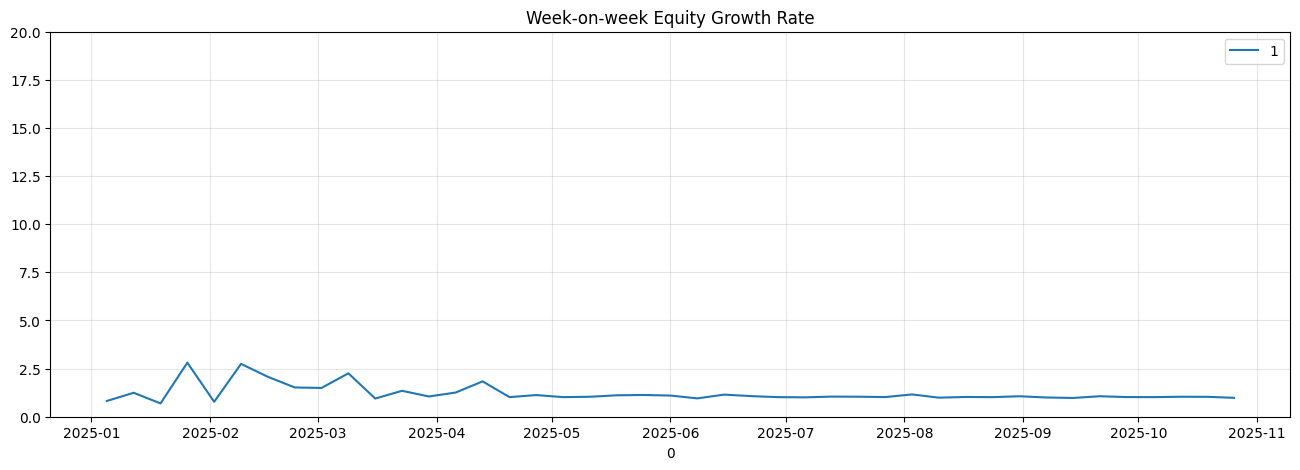

In [13]:
import datetime as dt
import numpy as np
cur_equity_set = []
week_on_week_equity = [[dt.datetime(2024, 12, 30).date(), np.float64(100.0)]]
week_on_week_equity_rate = []
cur_weekday = 0
last_weekday = 0
for row in equity_data.iterrows():
    cur_weekday = row[0].weekday()
    if cur_weekday >= last_weekday:
        cur_equity_set.append([row[0].date(), row[1][0]])
        last_weekday = cur_weekday
    elif cur_weekday < last_weekday:
        week_on_week_equity.append([cur_equity_set[-1][0], cur_equity_set[-1][1]])
        week_on_week_equity_rate.append([week_on_week_equity[-1][0] , week_on_week_equity[-1][1] / week_on_week_equity[-2][1]])
        cur_equity_set = []
        cur_equity_set.append([row[0].date(), row[1][0]])
        last_weekday = cur_weekday
        
week_on_week_equity_rate_df = pd.DataFrame(week_on_week_equity_rate)

fig3, ax3 = plt.subplots(figsize=(16, 5))

# Primary axis: Equity
# line1 = plot_data_equity.plot(, color='steelblue', label='Equity')
line1 = week_on_week_equity_rate_df.plot(ax=ax3, x=0, y=1, figsize=(16,5), title="Week-on-week Equity Growth Rate")
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 20])

# ax1.set_ylabel("Equity Value", color='steelblue')
# ax1.tick_params(axis='y', labelcolor='steelblue')



/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_58401/3011257214.py:39: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



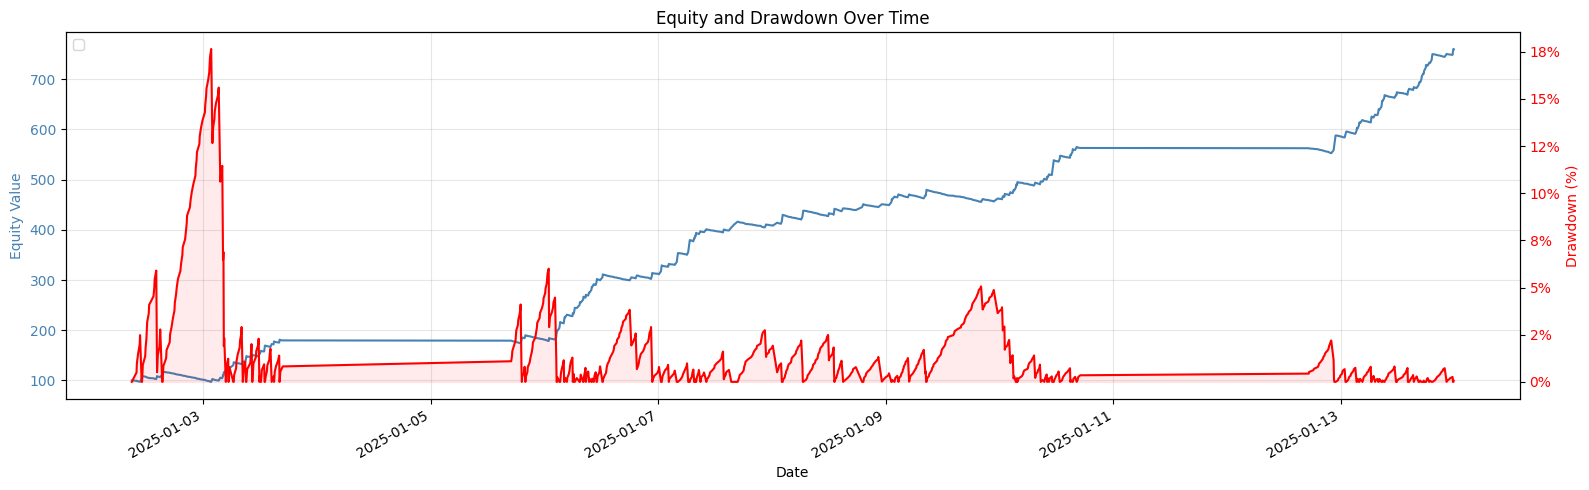

In [13]:
start_plot_date = "2025-01-01 00:00:00+00:00" #xxxxxxxxx
end_plot_date = "2025-01-14 00:00:00+00:00"

# Define the data to be plotted
plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

import matplotlib.pyplot as plt

# Assumes:
#   plot_data_equity: pandas Series indexed by datetime
#   plot_data_drawdown: pandas Series (percent values, e.g. 0–30) indexed by same datetime
# If indexes differ, you can align first: common_index = plot_data_equity.index.intersection(plot_data_drawdown.index)

fig, ax1 = plt.subplots(figsize=(16, 5))

# Primary axis: Equity
line1 = plot_data_equity.plot(ax=ax1, color='steelblue', label='Equity')
ax1.set_xlabel("Date")
ax1.set_ylabel("Equity Value", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Secondary axis: Drawdown %
ax2 = ax1.twinx()
line2 = plot_data_drawdown.plot(ax=ax2, color='red', label='Drawdown %')
ax2.set_ylabel("Drawdown (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Optional: format drawdown y-axis as integer percentages
from matplotlib.ticker import PercentFormatter
ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Grid (use primary axis grid so it doesn’t duplicate)
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Equity and Drawdown Over Time")
plt.tight_layout()

ax2.fill_between(plot_data_drawdown.index,
                plot_data_drawdown,
                0,
                color='red',
                alpha=0.08,
                label='_nolegend_')
plt.show()

(0.0, 20.0)

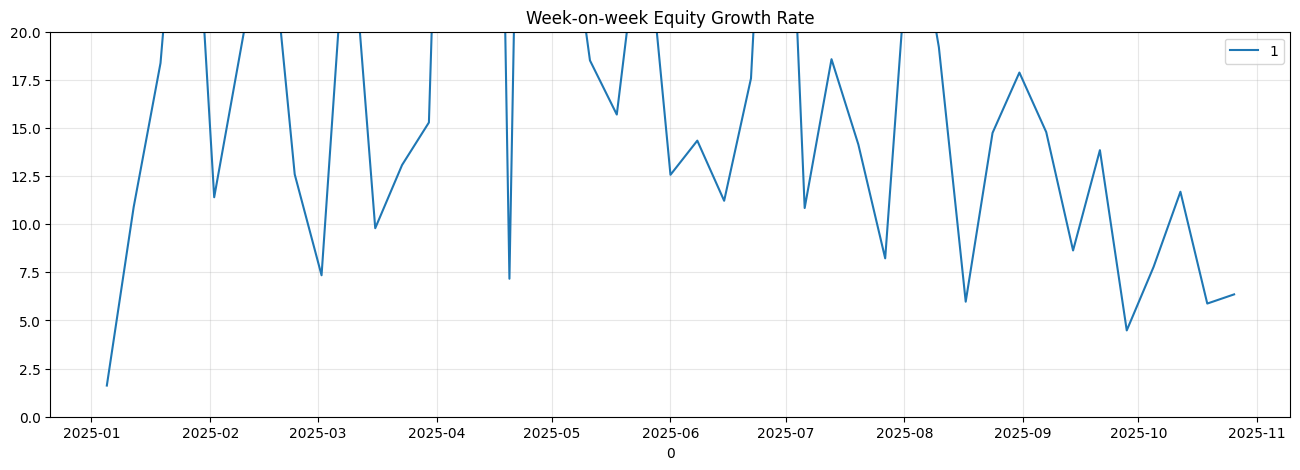

In [94]:
fig, ax2 = plt.subplots(figsize=(16, 5))

# Primary axis: Equity
# line1 = plot_data_equity.plot(, color='steelblue', label='Equity')
line1 = week_on_week_equity_rate_df.plot(ax=ax2, x=0, y=1, figsize=(16,5), title="Week-on-week Equity Growth Rate")
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 20])

# ax1.set_ylabel("Equity Value", color='steelblue')
# ax1.tick_params(axis='y', labelcolor='steelblue')



/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/2146034527.py:39: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



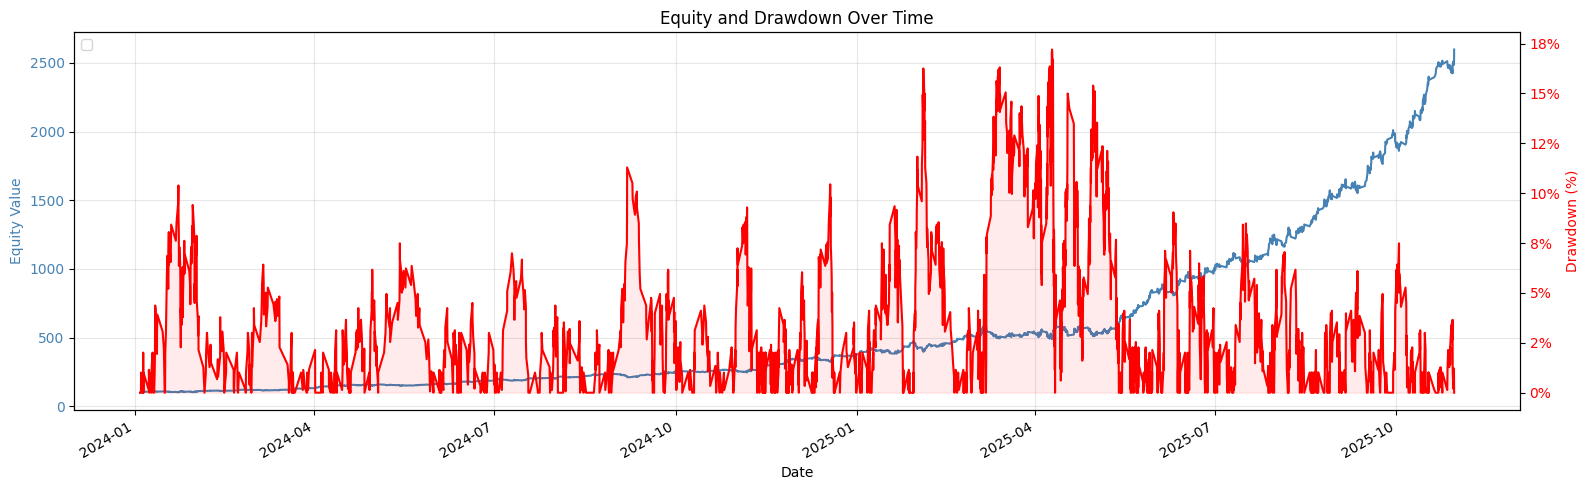

In [67]:
start_plot_date = "2023-01-01 00:00:00+00:00"
end_plot_date = "2025-12-01 00:00:00+00:00"

# Define the data to be plotted
plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

import matplotlib.pyplot as plt

# Assumes:
#   plot_data_equity: pandas Series indexed by datetime
#   plot_data_drawdown: pandas Series (percent values, e.g. 0–30) indexed by same datetime
# If indexes differ, you can align first: common_index = plot_data_equity.index.intersection(plot_data_drawdown.index)

fig, ax1 = plt.subplots(figsize=(16, 5))

# Primary axis: Equity
line1 = plot_data_equity.plot(ax=ax1, color='steelblue', label='Equity')
ax1.set_xlabel("Date")
ax1.set_ylabel("Equity Value", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Secondary axis: Drawdown %
ax2 = ax1.twinx()
line2 = plot_data_drawdown.plot(ax=ax2, color='red', label='Drawdown %')
ax2.set_ylabel("Drawdown (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Optional: format drawdown y-axis as integer percentages
from matplotlib.ticker import PercentFormatter
ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Grid (use primary axis grid so it doesn’t duplicate)
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Equity and Drawdown Over Time")
plt.tight_layout()

ax2.fill_between(plot_data_drawdown.index,
                 plot_data_drawdown,
                 0,
                 color='red',
                 alpha=0.08,
                 label='_nolegend_')
plt.show()

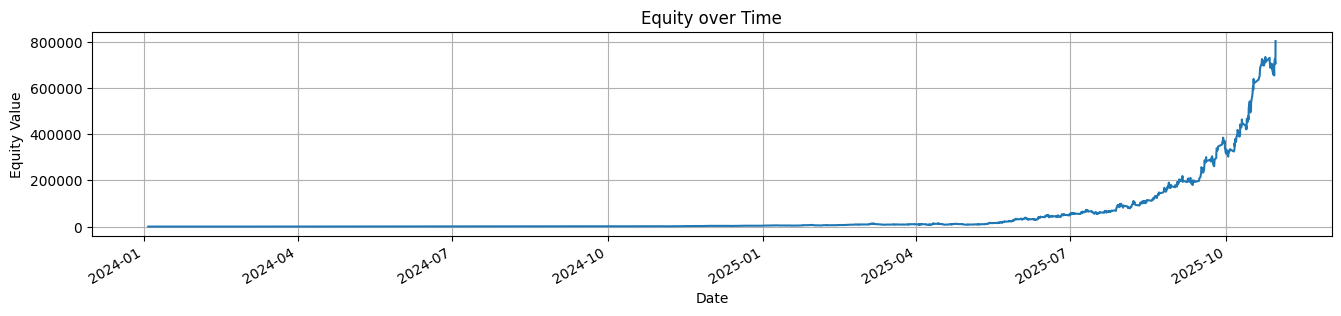

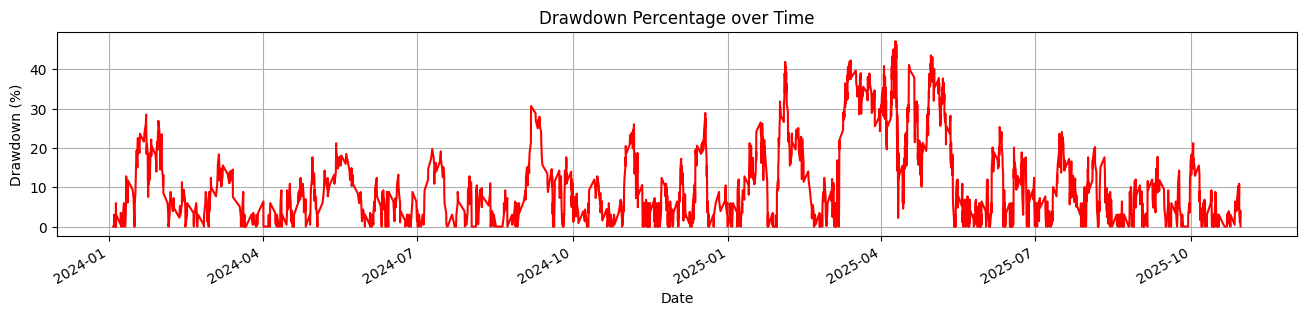

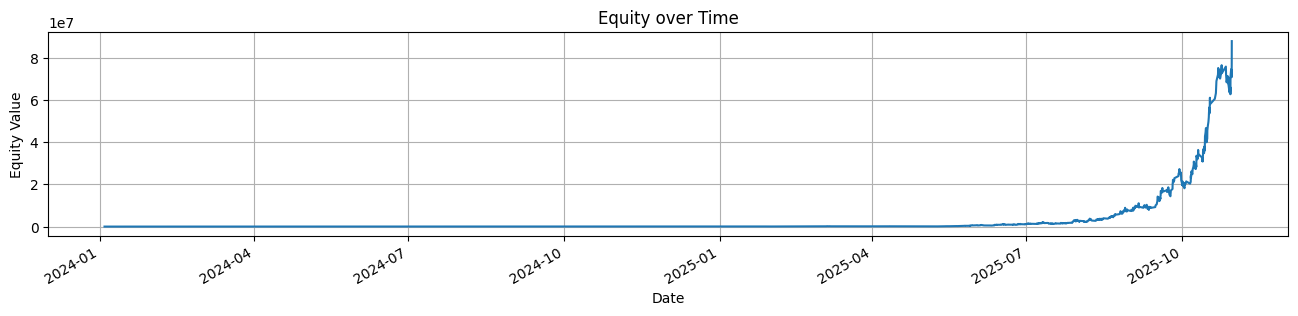

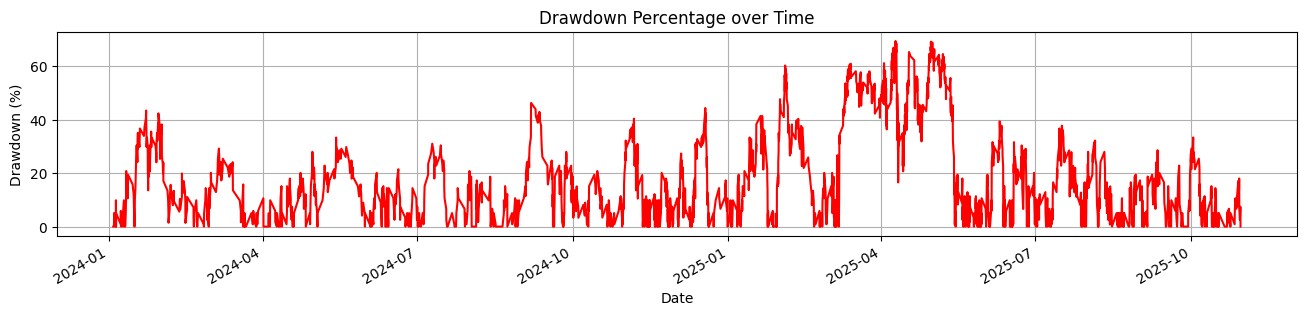

In [62]:
start_plot_date = "2023-01-01 00:00:00+00:00"
end_plot_date = "2025-12-01 00:00:00+00:00"

# Define the data to be plotted
plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

# Create the first figure and plot the 'Equity' data
plt.figure(figsize=(16, 3))  # Optional: specify figure size
plot_data_equity.plot(title='Equity over Time')
plt.xlabel("Date")
plt.ylabel("Equity Value")
plt.grid(True)

# Create the second figure and plot the 'DrawdownPerc' data
plt.figure(figsize=(16, 3))  # Optional: specify figure size
plot_data_drawdown.plot(title='Drawdown Percentage over Time', color='red')
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)

# Display the figures
plt.show()


In [63]:
0.2888 // 0.1

2.0